<a href="https://colab.research.google.com/github/naiaraaltuna/cozumel-reef-resilience/blob/main/01_Diversidad.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Proyecto de Diversidad
---
<br>

##"Salud arrecifal en Cozumel (2015–2024): resiliencia sostenida y su quiebre en el evento de blanqueamiento de 2024"
<br>

###OBJETIVO
Analizar si la trayectoria de salud del arrecife en Cozumel (2015–2024) se distingue del promedio de otras subregiones de Quintana Roo, y explorar su relación temporal con eventos de estrés térmico (DHW) y patrones de ocurrencia de coral reportados en GBIF.

<br>

##Preguntas que responde

###Nivel 1 — Descriptivas:

1. ¿Cómo ha cambiado el Índice de Salud del Arrecife en Cozumel entre 2015 y 2024, comparado con el promedio nacional mexicano y con las demás subregiones de Quintana Roo (Norte, Centro, Sur, Chinchorro)?

2. ¿En qué años Cozumel se desvía más del promedio regional — y coincide esa desviación con periodos de mayor o menor estrés térmico (DHW) según NOAA?

3. ¿Qué patrón muestran las ocurrencias reportadas de especies de coral (GBIF) en Quintana Roo a lo largo del mismo periodo — aumentan, disminuyen, o simplemente reflejan más esfuerzo de muestreo (más registros de iNaturalist con el tiempo)?

###Nivel 2 — Exploratoria
4. ¿Hay coincidencia temporal (no causalidad) entre picos de DHW y caídas en el índice de salud?







##1.Bases de datos

#####Variable explicativa:  serie temporal de estrés térmico (DHW) para Quintana Roo, NOAA CRW.

#####Variable de contexto: ocurrencias de especies arrecifales (coral, peces) vía GBIF, filtrado a Quintana Roo.

#####Variable de resultado (limitada, pero legítima: transcripción a mano el Reef Health Index de Cozumel vs. promedio regional de los report cards publicados en PDF (2008, 2010, 2012... 2024).


### 1.1 Estrés térmico (DHW) para Quintana Roo, NOAA CRW.

	•	Fuente: NOAA Coral Reef Watch, estación virtual Quintana Roo
	•	Acceso: descarga directa vía requests, sin autenticación. Archivo de texto plano con serie diaria desde 1985.
	•	Variable clave: DHW_from_90th_HS>1 (Degree Heating Weeks) — métrica estándar de la comunidad científica para predecir riesgo de blanqueamiento coralino, no una simple lectura de temperatura.
	•	Nota técnica: el archivo trae un bloque de metadatos antes de la tabla real; fue necesario ubicar programáticamente la fila de encabezado (YYYY MM DD ...) antes de parsear con pandas.

In [ ]:
import requests
import pandas as pd
from io import StringIO

url = "https://coralreefwatch.noaa.gov/product/vs/data/quintana_roo.txt"
texto = requests.get(url).text

# buscamos dónde empieza la tabla real (la línea del encabezado)
lineas = texto.split('\n')
for i, linea in enumerate(lineas):
    if linea.strip().startswith('YYYY'):
        inicio = i
        break

# reconstruimos el texto solo desde ahí
texto_tabla = '\n'.join(lineas[inicio:])

df_dhw = pd.read_csv(StringIO(texto_tabla), sep=r'\s+')
df_dhw.head()

,YYYY,MM,DD,SST_MIN,SST_MAX,SST@90th_HS,SSTA@90th_HS,90th_HS>0,DHW_from_90th_HS>1,BAA_7day_max
0,1985,1,1,26.21,27.01,26.93,0.4029,0.0,0.0,0
1,1985,1,2,26.38,27.09,26.84,0.4932,0.0,0.0,0
2,1985,1,3,26.21,27.00,26.99,0.3245,0.0,0.0,0
3,1985,1,4,25.77,26.83,26.73,0.0394,0.0,0.0,0
4,1985,1,5,24.81,26.42,26.28,-0.3597,0.0,0.0,0


###1.2 Ocurrencias de coral — GBIF (Global Biodiversity Information Facility)

	•	Fuente: API pública de GBIF, filtrada a phylum Cnidaria en México.
	•	Acceso: API REST sin autenticación para consultas de este tamaño.
	•	Decisión metodológica: el filtro taxonómico se aplicó vía phylumKey=43 (código numérico de Cnidaria en la taxonomía GBIF), no vía el nombre en texto (phylum=Cnidaria), ya que este último parámetro no existe en la API y es ignorado silenciosamente sin generar error — un punto de fricción no documentado de forma evidente en la referencia rápida de la API.
	•	Decisión metodológica: la delimitación geográfica a Quintana Roo se hizo por coordenadas (decimalLatitude/decimalLongitude) en lugar del campo stateProvince, porque este último es texto libre inconsistente entre instituciones publicadoras.
	•	Limitación reconocida: estos son registros de esfuerzo de observación ciudadana (mayoritariamente iNaturalist), no un censo biológico. Un cambio en el número de ocurrencias reportadas puede reflejar cambios en el comportamiento humano de reporte (turismo, actividad de buceo) tanto como cambios reales en la población de coral. El análisis trata la composición taxonómica de los reportes (qué familias de coral se reportan, no solo cuántas) como señal parcialmente más robusta que el conteo bruto.


Se deja registro en el siguiente markdown del código usado para crear la base de datos de cnidarios en Quintana Roo con fines de su reproducibilidad.
Aplicado este código se guardo copia independiente por facilidad de trabajo por volumen de datos en la base original.

 #### 1.2.1 Código de extracción de datos mediante la API de GBIF
import requests
import pandas as pd

### Parámetros de búsqueda
params = {
    "country": "MX",
    "phylumKey": 43,                 # Cnidaria
    "hasCoordinate": "true",
    "geometry": "POLYGON((-89.0 17.8,-86.7 17.8,-86.7 21.6,-89.0 21.6,-89.0 17.8))",
    "limit": 300
}

todos_los_resultados = []
offset = 0

while True:
    params["offset"] = offset

    response = requests.get(
        "https://api.gbif.org/v1/occurrence/search",
        params=params,
        timeout=30
    )

    response.raise_for_status()

    data = response.json()
    resultados = data["results"]

    if not resultados:
        break

    todos_los_resultados.extend(resultados)

    print(f"Descargados: {len(todos_los_resultados):,} / {data['count']:,}")

    offset += params["limit"]

    if offset >= data["count"]:
        break

#### Convertir a DataFrame
df_gbif_qroo = pd.DataFrame(todos_los_resultados)

<br>

#### Conservar únicamente las columnas de interés
columnas_utiles = [
    "scientificName",
    "class",
    "order",
    "family",
    "decimalLatitude",
    "decimalLongitude",
    "eventDate",
    "basisOfRecord",
    "institutionCode"
]

df_gbif_qroo = df_gbif_qroo[
    [c for c in columnas_utiles if c in df_gbif_qroo.columns]
].copy()

print("\nTotal de registros:", len(df_gbif_qroo))

df_gbif_qroo.head()

In [ ]:

import pandas as pd

url = "https://raw.githubusercontent.com/naiaraaltuna/cozumel-reef-resilience/main/data/gbif_qroo_cnidaria.csv"

df_gbif_qroo = pd.read_csv(url)

print(df_gbif_qroo.shape)
df_gbif_qroo.head()

(17408, 9)


,scientificName,class,order,family,decimalLatitude,decimalLongitude,eventDate,basisOfRecord,institutionCode
0,"Gorgonia ventalina Linnaeus, 1758",Anthozoa,Malacalcyonacea,Gorgoniidae,19.309608,-87.618179,2026-01-02T15:17:14,HUMAN_OBSERVATION,iNaturalist
1,"Gorgonia ventalina Linnaeus, 1758",Anthozoa,Malacalcyonacea,Gorgoniidae,19.671281,-87.575935,2026-01-02T15:17:34,HUMAN_OBSERVATION,iNaturalist
2,"Gorgonia ventalina Linnaeus, 1758",Anthozoa,Malacalcyonacea,Gorgoniidae,19.654467,-87.553681,2026-01-02T15:19:06,HUMAN_OBSERVATION,iNaturalist
3,"Gorgonia ventalina Linnaeus, 1758",Anthozoa,Malacalcyonacea,Gorgoniidae,20.486284,-86.970725,2026-01-22T03:00,HUMAN_OBSERVATION,iNaturalist
4,"Stichodactyla helianthus (Ellis, 1768)",Anthozoa,Actiniaria,Stichodactylidae,20.485278,-86.970392,2026-01-23T13:10:19,HUMAN_OBSERVATION,iNaturalist


### 1.3 Importar tabla Reef Health Index manual

In [ ]:
import pandas as pd

url = "https://raw.githubusercontent.com/naiaraaltuna/cozumel-reef-resilience/main/data/reef_health_index_manual.csv"

df_report_cards = pd.read_csv(url, skiprows=1)

print(df_report_cards.shape)
df_report_cards.head()

(6, 11)


,Subregion,2015,2018,2020,2022,2024,%cover coral,% reef in protected areas,reef protected areas,reef_km2,#sites
0,MEXICO,3.8,2.8,2.8,2.8,2.8,13,15,49,332,70
1,North Q.R00,3.0,2.5,2.8,2.5,3.3,11,25,10,42,25
2,Cozumel,3.5,3.5,3.8,3.8,3.0,16,35,9,26,12
3,Central Q.ROO,2.8,2.3,2.5,2.0,2.3,12,9,6,71,16
4,South Q.ROO,2.5,2.3,2.8,2.8,2.8,12,9,3,31,11




### 1.3 Índice de Salud del Arrecife — Healthy Reefs Initiative / AGRRA Report Cards


	•	Fuente: Report Cards oficiales, PDF, años 2015, 2018, 2020, 2022 y 2024.
	•	Acceso: transcripción manual, verificada contra el documento original. No existe un dataset descargable ni API para este indicador; los report cards son documentos de diseño gráfico, no tablas estructuradas.
	•	Decisión de alcance: se excluyeron los reportes 2008–2012 porque no desagregan el índice por subregión de Quintana Roo (Norte, Centro, Sur, Cozumel, Chinchorro) con la misma metodología que los reportes 2015 en adelante. Incluirlos habría introducido una comparación inconsistente dentro de la misma serie temporal.
	•	Archivo versionado: data/reef_health_index_manual.csv, con columna de fuente citando el PDF de origen para cada valor, para que cualquier persona pueda auditar la transcripción sin repetir el proceso.




2024	https://cdn.prod.website-files.com/66b16833c7877e9078babf9d/67361e479ff8ca23dc49ebf7_2024%20Report%20Card%20-website%20version.pdf

2022	https://cdn.prod.website-files.com/66b16833c7877e9078babf9d/66edaf70667fe40b7b5aaa4c_2022_MAR_Report%20Card_LOres_compressed%202.pdf

2020	https://cdn.prod.website-files.com/66b16833c7877e9078babf9d/66edb22dfdfd67445bf65099_2020_Report_Card_MAR%20compressed_compressed.pdf

2018	https://cdn.prod.website-files.com/66b16833c7877e9078babf9d/66ed7a106ffc4167711d5602_2018-MAR-Report-Card-Web.pdf

2015	Google Drive: https://drive.google.com/file/d/1EdDkWWDH8t902T4sfg4qsM0_I8Mgm6Ta/view

2012	https://cdn.prod.website-files.com/66b16833c7877e9078babf9d/66ed81357c901bff800cedcd_2012-Report-Card.pdf

2010	Google Drive: https://drive.google.com/file/d/1f2lra8BHwTvW23Q0HykhzvhaT9-5LKxY/view

2008	Google Drive: https://drive.google.com/file/d/1poCjmk0553VOW_em0l7pKC4v3oB9Wtx6/view



##2.Limpieza de datos y calidad .


### 2.1 Datos NOAA. Preparación

Se creó una variable de fecha a partir de las columnas de año, mes y día, y se filtraron los registros correspondientes al período **2015–2024**. Finalmente, se verificó la presencia de valores faltantes en el conjunto de datos resultante.


In [ ]:
# NOAA
df_dhw['fecha'] = pd.to_datetime(df_dhw[['YYYY','MM','DD']].astype(str).agg('-'.join, axis=1))
df_dhw_recorte = df_dhw[(df_dhw['fecha'] >= '2015-01-01') & (df_dhw['fecha'] <= '2024-12-31')]
print(df_dhw_recorte.isna().sum())


YYYY                  0
MM                    0
DD                    0
SST_MIN               0
SST_MAX               0
SST@90th_HS           0
SSTA@90th_HS          0
90th_HS>0             0
DHW_from_90th_HS>1    0
BAA_7day_max          0
fecha                 0
dtype: int64


### 2.2 Datos de diversidad de GBIF



La variable **`eventDate`** se convirtió al formato de fecha (`datetime`) y los registros con fechas inválidas se transformaron en valores nulos (`NaT`).

Posteriormente, se filtró el conjunto de datos para conservar únicamente las ocurrencias registradas entre **2015 y 2024**.

Se realizó un conteo del número de registros por año con el objetivo de verificar la cobertura temporal y la distribución de las observaciones dentro del intervalo de análisis.


In [ ]:
# GBIF
df_gbif_qroo['eventDate'] = pd.to_datetime(df_gbif_qroo['eventDate'], errors='coerce')
df_gbif_recorte = df_gbif_qroo[
    (df_gbif_qroo['eventDate'].dt.year >= 2015) & (df_gbif_qroo['eventDate'].dt.year <= 2024)
]
print(df_gbif_recorte['eventDate'].dt.year.value_counts().sort_index())

eventDate
2015      5
2016      2
2017      3
2018     22
2019     44
2020     24
2021     26
2022    100
2023     89
2024     77
Name: count, dtype: int64


#### 2.2.1 Restricción de tabla

Al desagregar las ocurrencias de Cnidaria en Quintana Roo por año, se observa una distribución fuertemente desigual entre 2015 y 2024.

El salto entre 2017 (3 registros) y 2018 (22 registros) —y el crecimiento sostenido posterior— no es consistente con un cambio biológico real en ese margen de tiempo. Coincide con el periodo de adopción masiva de iNaturalist como plataforma de ciencia ciudadana. Esto confirma que el volumen de registros en GBIF refleja, al menos en parte, esfuerzo de observación humana y no exclusivamente presencia real de coral en el ecosistema.

Decisión metodológica: el análisis de composición taxonómica (proporción de familias de coral reportadas) se restringe al periodo 2018–2024, donde el volumen anual (22 a 100 registros) permite hablar de proporciones con un mínimo de estabilidad estadística. Los años 2015–2017 se excluyen de esta variable específica por tamaño de muestra insuficiente (2 a 5 registros por año), aunque se conservan en las series de estrés térmico (NOAA) y salud arrecifal (report cards), que no dependen de esfuerzo de muestreo ciudadano.

In [ ]:
df_gbif_2018_2024 = df_gbif_recorte[df_gbif_recorte['eventDate'].dt.year >= 2018].copy()

#### 2.2.2 Composición anual de las familias de Cnidaria

Se agruparon los registros por **año de ocurrencia** y **familia taxonómica**, obteniendo el número de observaciones para cada combinación de año y familia.

Posteriormente, la tabla de conteos se transformó en una matriz donde cada fila representa un año y cada columna una familia, asignando el valor **0** a las combinaciones sin registros.

Finalmente, los conteos absolutos se convirtieron en **porcentajes**, calculando la proporción que representa cada familia respecto al total de registros de su año correspondiente. Esta transformación permite comparar la composición taxonómica entre años independientemente del número total de observaciones registradas en cada período.


In [ ]:
composicion = (
    df_gbif_2018_2024
    .groupby([df_gbif_2018_2024['eventDate'].dt.year, 'family'])
    .size()
    .unstack(fill_value=0)
)

# convertir a proporciones (%) por año, no conteos crudos
composicion_pct = composicion.div(composicion.sum(axis=1), axis=0) * 100
composicion_pct

family,Acroporidae,Actiniidae,Agariciidae,Aiptasiidae,Aliciidae,Boloceroididae,Briareidae,Carybdeidae,Cassiopeidae,Faviidae,...,Poritidae,Porpitidae,Pterogorgiidae,Rhizangiidae,Rhopalonematidae,Sphenopidae,Stichodactylidae,Stylasteridae,Ulmaridae,Zoanthidae
eventDate,,,,,,,,,,,,,,,,,,,,,
2018,14.285714,7.142857,0.000000,7.142857,0.000000,0.000000,7.142857,7.142857,7.142857,7.142857,...,0.000000,0.000000,0.000000,7.142857,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2019,6.818182,11.363636,2.272727,2.272727,0.000000,0.000000,4.545455,0.000000,0.000000,15.909091,...,6.818182,0.000000,0.000000,6.818182,0.000000,0.000000,0.000000,0.000000,2.272727,0.000000
2020,0.000000,20.833333,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4.166667,8.333333,...,8.333333,0.000000,0.000000,0.000000,4.166667,8.333333,4.166667,0.000000,4.166667,0.000000
2021,3.846154,30.769231,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.846154,7.692308,...,3.846154,3.846154,0.000000,0.000000,0.000000,3.846154,3.846154,0.000000,0.000000,0.000000
2022,3.000000,3.000000,9.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,10.000000,...,9.000000,0.000000,1.000000,5.000000,0.000000,4.000000,0.000000,2.000000,0.000000,0.000000
2023,4.494382,13.483146,4.494382,0.000000,1.123596,0.000000,0.000000,0.000000,1.123596,14.606742,...,4.494382,0.000000,1.123596,2.247191,0.000000,4.494382,4.494382,0.000000,0.000000,0.000000
2024,3.896104,5.194805,0.000000,0.000000,1.298701,1.298701,0.000000,0.000000,2.597403,11.688312,...,6.493506,1.298701,0.000000,0.000000,0.000000,6.493506,3.896104,1.298701,0.000000,1.298701


In [ ]:
print(df_gbif_2018_2024['family'].value_counts())

family
Gorgoniidae          104
Faviidae              44
Actiniidae            38
Poritidae             24
Acroporidae           16
Sphenopidae           16
Agariciidae           14
Milleporidae          13
Merulinidae           13
Plexauridae           12
Rhizangiidae          11
Stichodactylidae       9
Montastraeidae         9
Cassiopeidae           7
Melithaeidae           6
Meandrinidae           5
Pennariidae            4
Stylasteridae          3
Hydrozoanthidae        3
Briareidae             3
Physaliidae            3
Aiptasiidae            2
Ulmaridae              2
Aliciidae              2
Pterogorgiidae         2
Porpitidae             2
Boloceroididae         1
Zoanthidae             1
Homostichanthidae      1
Pocilloporidae         1
Parazoanthidae         1
Rhopalonematidae       1
Carybdeidae            1
Name: count, dtype: int64


#### 2.2.3 Refinamiento del filtro taxonómico

El filtro inicial por `phylumKey=43` (Cnidaria) captura correctamente todo el phylum,
pero este incluye organismos que no son coral: anémonas de mar (ej. Actiniidae,
Stichodactylidae), medusas e hidrozoos flotantes (ej. Cassiopeidae, Physaliidae,
Carybdeidae). Como el análisis de composición taxonómica busca específicamente
patrones en coral formador de arrecife, se refina el filtro a nivel de familia,
conservando solo las asociadas a coral duro y blando.

In [ ]:
familias_coral = [
    'Gorgoniidae', 'Faviidae', 'Poritidae', 'Acroporidae', 'Agariciidae',
    'Milleporidae', 'Merulinidae', 'Plexauridae', 'Montastraeidae',
    'Meandrinidae', 'Melithaeidae', 'Briareidae', 'Pterogorgiidae',
    'Pocilloporidae', 'Rhizangiidae', 'Sphenopidae'
]

df_coral_solo = df_gbif_2018_2024[df_gbif_2018_2024['family'].isin(familias_coral)].copy()
print(df_coral_solo['family'].value_counts())

family
Gorgoniidae       104
Faviidae           44
Poritidae          24
Acroporidae        16
Sphenopidae        16
Agariciidae        14
Milleporidae       13
Merulinidae        13
Plexauridae        12
Rhizangiidae       11
Montastraeidae      9
Melithaeidae        6
Meandrinidae        5
Briareidae          3
Pterogorgiidae      2
Pocilloporidae      1
Name: count, dtype: int64


In [ ]:
# Filtro inicial (todo Cnidaria) — mantenido como referencia del universo original
print(df_gbif_2018_2024['family'].value_counts())

family
Gorgoniidae          104
Faviidae              44
Actiniidae            38
Poritidae             24
Acroporidae           16
Sphenopidae           16
Agariciidae           14
Milleporidae          13
Merulinidae           13
Plexauridae           12
Rhizangiidae          11
Stichodactylidae       9
Montastraeidae         9
Cassiopeidae           7
Melithaeidae           6
Meandrinidae           5
Pennariidae            4
Stylasteridae          3
Hydrozoanthidae        3
Briareidae             3
Physaliidae            3
Aiptasiidae            2
Ulmaridae              2
Aliciidae              2
Pterogorgiidae         2
Porpitidae             2
Boloceroididae         1
Zoanthidae             1
Homostichanthidae      1
Pocilloporidae         1
Parazoanthidae         1
Rhopalonematidae       1
Carybdeidae            1
Name: count, dtype: int64


In [ ]:
# Refinamiento: solo familias de coral (duro y blando), excluyendo anémonas,
# medusas e hidrozoos flotantes que también pertenecen a Cnidaria
familias_coral = [
    'Gorgoniidae', 'Faviidae', 'Poritidae', 'Acroporidae', 'Agariciidae',
    'Milleporidae', 'Merulinidae', 'Plexauridae', 'Montastraeidae',
    'Meandrinidae', 'Melithaeidae', 'Briareidae', 'Pterogorgiidae',
    'Pocilloporidae', 'Rhizangiidae', 'Sphenopidae'
]

df_coral_solo = df_gbif_2018_2024[df_gbif_2018_2024['family'].isin(familias_coral)].copy()
print(f"Registros tras refinamiento: {len(df_coral_solo)} de {len(df_gbif_2018_2024)} originales")
df_coral_solo['family'].value_counts()

Registros tras refinamiento: 293 de 382 originales


,count
family,
Gorgoniidae,104
Faviidae,44
Poritidae,24
Acroporidae,16
Sphenopidae,16
Agariciidae,14
Milleporidae,13
Merulinidae,13
Plexauridae,12


In [ ]:
composicion_coral = (
    df_coral_solo
    .groupby([df_coral_solo['eventDate'].dt.year, 'family'])
    .size()
    .unstack(fill_value=0)
)

composicion_coral_pct = composicion_coral.div(composicion_coral.sum(axis=1), axis=0) * 100
composicion_coral_pct

family,Acroporidae,Agariciidae,Briareidae,Faviidae,Gorgoniidae,Meandrinidae,Melithaeidae,Merulinidae,Milleporidae,Montastraeidae,Plexauridae,Pocilloporidae,Poritidae,Pterogorgiidae,Rhizangiidae,Sphenopidae
eventDate,,,,,,,,,,,,,,,,
2018,22.222222,0.000000,11.111111,11.111111,22.222222,0.000000,0.000000,0.000000,0.000000,11.111111,11.111111,0.000000,0.000000,0.000000,11.111111,0.000000
2019,8.108108,2.702703,5.405405,18.918919,21.621622,8.108108,0.000000,8.108108,8.108108,0.000000,2.702703,0.000000,8.108108,0.000000,8.108108,0.000000
2020,0.000000,0.000000,0.000000,13.333333,46.666667,6.666667,0.000000,0.000000,0.000000,0.000000,6.666667,0.000000,13.333333,0.000000,0.000000,13.333333
2021,6.666667,0.000000,0.000000,13.333333,60.000000,0.000000,0.000000,0.000000,6.666667,0.000000,0.000000,0.000000,6.666667,0.000000,0.000000,6.666667
2022,3.448276,10.344828,0.000000,11.494253,34.482759,0.000000,5.747126,1.149425,6.896552,4.597701,0.000000,0.000000,10.344828,1.149425,5.747126,4.597701
2023,5.714286,5.714286,0.000000,18.571429,30.000000,0.000000,1.428571,8.571429,2.857143,4.285714,5.714286,1.428571,5.714286,1.428571,2.857143,5.714286
2024,5.000000,0.000000,0.000000,15.000000,45.000000,1.666667,0.000000,5.000000,1.666667,1.666667,8.333333,0.000000,8.333333,0.000000,0.000000,8.333333


####2.2.4 Simplificación de la composición taxonómica

Se identificaron las **cinco familias de corales con mayor número de registros** en el conjunto de datos. Posteriormente, todas las familias restantes se agruparon en una única categoría denominada **"Otras"**, con el fin de simplificar la interpretación y visualización de los resultados.

Finalmente, los conteos de registros se transformaron en **porcentajes**, calculando la proporción que representa cada una de las cinco familias principales y la categoría **"Otras"** respecto al total de registros de cada año. Esta estandarización permite comparar la composición relativa de las familias a lo largo del tiempo, independientemente de las diferencias en el número total de observaciones registradas en cada año.


In [ ]:
top_familias = df_coral_solo['family'].value_counts().head(5).index.tolist()
print("Top 5 familias:", top_familias)

composicion_coral['Otras'] = composicion_coral.drop(
    columns=[c for c in composicion_coral.columns if c in top_familias]
).sum(axis=1)

composicion_final = composicion_coral[top_familias + ['Otras']]
composicion_final_pct = composicion_final.div(composicion_final.sum(axis=1), axis=0) * 100
composicion_final_pct

Top 5 familias: ['Gorgoniidae', 'Faviidae', 'Poritidae', 'Acroporidae', 'Sphenopidae']


family,Gorgoniidae,Faviidae,Poritidae,Acroporidae,Sphenopidae,Otras
eventDate,,,,,,
2018,22.222222,11.111111,0.000000,22.222222,0.000000,44.444444
2019,21.621622,18.918919,8.108108,8.108108,0.000000,43.243243
2020,46.666667,13.333333,13.333333,0.000000,13.333333,13.333333
2021,60.000000,13.333333,6.666667,6.666667,6.666667,6.666667
2022,34.482759,11.494253,10.344828,3.448276,4.597701,35.632184
2023,30.000000,18.571429,5.714286,5.714286,5.714286,34.285714
2024,45.000000,15.000000,8.333333,5.000000,8.333333,18.333333


In [ ]:
print(df_coral_solo.groupby(df_coral_solo['eventDate'].dt.year).size())

eventDate
2018     9
2019    37
2020    15
2021    15
2022    87
2023    70
2024    60
dtype: int64


In [ ]:
n_por_año = df_coral_solo.groupby(df_coral_solo['eventDate'].dt.year).size()
umbral_minimo = 30  # criterio arbitrario razonable, decide y documenta por qué

años_confiables = n_por_año[n_por_año >= umbral_minimo].index.tolist()
años_baja_muestra = n_por_año[n_por_año < umbral_minimo].index.tolist()

print("Años con muestra suficiente (N≥30):", años_confiables)
print("Años con muestra insuficiente (N<30):", años_baja_muestra)

Años con muestra suficiente (N≥30): [2019, 2022, 2023, 2024]
Años con muestra insuficiente (N<30): [2018, 2020, 2021]


##### 2.2.4.1 Ruido en Taxonomía

Los años 2018, 2020 y 2021 registran un volumen de observaciones (N=9, 15, 15
respectivamente) insuficiente para una lectura confiable de composición
taxonómica. Se conservan en la visualización por transparencia, pero las
proporciones de esos años deben interpretarse como ruido de muestra, no como
tendencia. Los años con N≥30 (2019, 2022, 2023, 2024) son la base más sólida
para cualquier lectura de cambio en composición taxonómica.

Caída de muestra en 2020–2021: una explicación alternativa a la biológica

Al desagregar el volumen anual dentro de la ventana 2018–2024, los años 2018, 2020 y 2021 muestran un número de observaciones notablemente bajo (N=9, 15 y 15, respectivamente) frente a 2019, 2022, 2023 y 2024 (N=37 a 87). La caída de 2020–2021 en particular coincide con el periodo de mayor restricción a la movilidad y al turismo internacional por la pandemia de COVID-19, que redujo drásticamente la actividad de buceo y snorkel en el Caribe Mexicano — la fuente principal de observaciones de coral en iNaturalist, dado que estas dependen de que una persona esté físicamente en el arrecife para fotografiarlo.

Esta es una explicación más simple y más verificable que cualquier hipótesis que atribuya la caída de registros a un mecanismo biológico (por ejemplo, menor presencia real de coral). No hay necesidad de invocar estrés térmico, blanqueamiento u otro proceso ecológico para explicar el patrón: una caída generalizada y temporal en la actividad turística explica la caída de muestra sin requerir ningún cambio en el ecosistema.

Implicación para el análisis: cualquier variación en la composición taxonómica observada en 2020–2021 debe leerse primero como posible artefacto de baja muestra asociado a la pandemia, antes que como señal de cambio ecológico. Esto no invalida el uso de esos años en el análisis, pero exige tratarlos con menor peso interpretativo que los años con muestra más robusta.

###3.2 Indice de salud arrecifal por región (2015-2024)

Se agruparon los datos de Degree Heating Weeks (DHW) en ventanas temporales de dos o tres años. Para cada período, se calculó el valor promedio de DHW, obteniendo un indicador representativo del nivel de estrés térmico registrado en cada intervalo

In [ ]:
url_csv = "https://raw.githubusercontent.com/naiaraaltuna/cozumel-reef-resilience/main/data/reef_health_index_manual.csv"
df_raw = pd.read_csv(url_csv, skiprows=1)
print(df_raw.columns.tolist())
print(df_raw.head())

['Subregion', '2015', '2018', '2020', '2022', '2024', '%cover coral', '% reef in protected areas', 'reef protected areas ', 'reef_km2', '#sites']
       Subregion  2015  2018  2020  2022  2024  %cover coral  \
0         MEXICO   3.8   2.8   2.8   2.8   2.8            13   
1    North Q.R00   3.0   2.5   2.8   2.5   3.3            11   
2        Cozumel   3.5   3.5   3.8   3.8   3.0            16   
3  Central Q.ROO   2.8   2.3   2.5   2.0   2.3            12   
4    South Q.ROO   2.5   2.3   2.8   2.8   2.8            12   

   % reef in protected areas  reef protected areas   reef_km2  #sites  
0                         15                     49       332      70  
1                         25                     10        42      25  
2                         35                      9        26      12  
3                          9                      6        71      16  
4                          9                      3        31      11  


In [ ]:
columnas_años = ['2015', '2018', '2020', '2022', '2024']

df_report_cards = df_raw.melt(
    id_vars=['Subregion'],
    value_vars=columnas_años,
    var_name='año',
    value_name='indice_salud'
)
df_report_cards['año'] = df_report_cards['año'].astype(int)
df_report_cards = df_report_cards.rename(columns={'Subregion': 'subregion'})

df_contexto = df_raw[[
    'Subregion', '%cover coral', '% reef in protected areas',
    'reef protected areas ', 'reef_km2', '#sites'
]].copy()
df_contexto = df_contexto.rename(columns={'Subregion': 'subregion'})

print(df_report_cards.head(10))
print(df_contexto.head())

       subregion   año  indice_salud
0         MEXICO  2015           3.8
1    North Q.R00  2015           3.0
2        Cozumel  2015           3.5
3  Central Q.ROO  2015           2.8
4    South Q.ROO  2015           2.5
5     Chinchorro  2015           2.5
6         MEXICO  2018           2.8
7    North Q.R00  2018           2.5
8        Cozumel  2018           3.5
9  Central Q.ROO  2018           2.3
       subregion  %cover coral  % reef in protected areas  \
0         MEXICO            13                         15   
1    North Q.R00            11                         25   
2        Cozumel            16                         35   
3  Central Q.ROO            12                          9   
4    South Q.ROO            12                          9   

   reef protected areas   reef_km2  #sites  
0                     49       332      70  
1                     10        42      25  
2                      9        26      12  
3                      6        71      16  
4

In [ ]:
ventanas = [(2013, 2015), (2016, 2018), (2019, 2020), (2021, 2022), (2023, 2024)]
resultados_dhw = []
for inicio, fin in ventanas:
    mask = (df_dhw_recorte['fecha'].dt.year >= inicio) & (df_dhw_recorte['fecha'].dt.year <= fin)
    dhw_promedio = df_dhw_recorte.loc[mask, 'DHW_from_90th_HS>1'].mean()
    resultados_dhw.append({'año': fin, 'dhw_promedio_ventana': dhw_promedio})

df_dhw_agregado = pd.DataFrame(resultados_dhw)
print(df_dhw_agregado)

    año  dhw_promedio_ventana
0  2015              2.251424
1  2018              1.773275
2  2020              3.723775
3  2022              1.616545
4  2024              6.953252


## 3.Gráficas

### 3.1 Composición taxonómica de coral reportado en GBIF (Quintana Roo, 2018-2024)



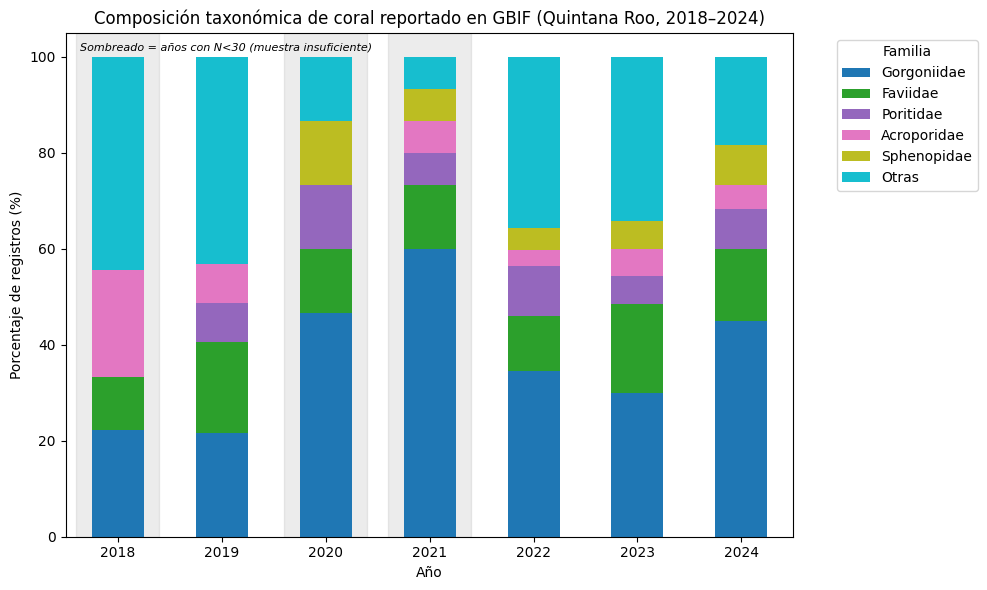

In [ ]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 6))
composicion_final_pct.plot(kind='bar', stacked=True, ax=ax, colormap='tab10')
ax.set_title('Composición taxonómica de coral reportado en GBIF (Quintana Roo, 2018–2024)')
ax.set_xlabel('Año')
ax.set_ylabel('Porcentaje de registros (%)')
ax.legend(title='Familia', bbox_to_anchor=(1.05, 1), loc='upper left')

años_baja_muestra = [2018, 2020, 2021]
for año in años_baja_muestra:
    if año in composicion_final_pct.index:
        pos = list(composicion_final_pct.index).index(año)
        ax.axvspan(pos - 0.4, pos + 0.4, color='gray', alpha=0.15, zorder=0)
ax.text(0.02, 0.98, 'Sombreado = años con N<30 (muestra insuficiente)',
        transform=ax.transAxes, fontsize=8, va='top', style='italic')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

El patrón dominante que se observa (el salto de Gorgoniidae en 2020-2021) es más consistente con artefacto de muestra reducida por la caída de turismo en pandemia que con una señal biológica real, tal como documentamos en el markdown. No hay, en esta gráfica sola, evidencia de una tendencia clara y sostenida de cambio de composición a lo largo del periodo — los años con muestra robusta (2019, 2022, 2023, 2024) muestran proporciones relativamente estables entre sí,

### 3.2 Indice de Salud del Arrecife por subregión (2025-2024)

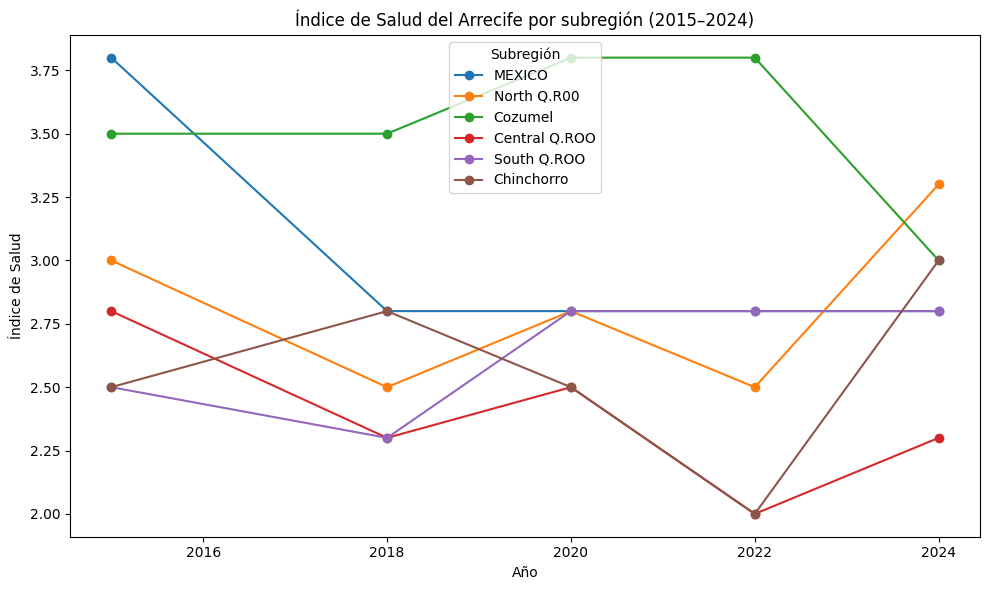

In [ ]:
# Gráfico 2 — todas las subregiones
fig, ax = plt.subplots(figsize=(10, 6))
for subregion in df_report_cards['subregion'].unique():
    datos = df_report_cards[df_report_cards['subregion'] == subregion]
    ax.plot(datos['año'], datos['indice_salud'], marker='o', label=subregion)
ax.set_title('Índice de Salud del Arrecife por subregión (2015–2024)')
ax.set_xlabel('Año')
ax.set_ylabel('Índice de Salud')
ax.legend(title='Subregión')
plt.tight_layout()
plt.show()

La figura indica que Cozumel ha mantenido consistentemente el mejor estado de salud arrecifal, mientras que Central Q. Roo presenta los valores más bajos durante gran parte del período analizado. Por su parte, North Q. Roo y Chinchorro muestran una recuperación notable en 2024, mientras que South Q. Roo permanece relativamente estable. Estos resultados evidencian que la condición de los arrecifes no evoluciona de manera uniforme entre las distintas subregiones de Quintana Roo.

### 3.3 Indice de Salud y Estrés Termico (2025-2024)

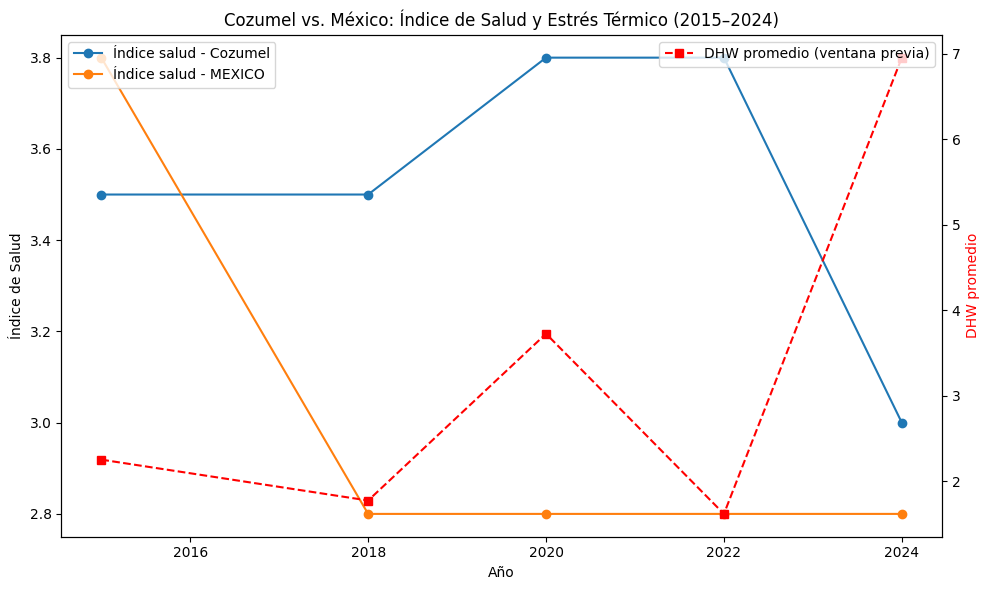

In [ ]:
# Gráfico 3 — Cozumel vs. México, con DHW superpuesto
fig, ax1 = plt.subplots(figsize=(10, 6))
for subregion in ['Cozumel', 'MEXICO']:
    datos = df_report_cards[df_report_cards['subregion'] == subregion]
    ax1.plot(datos['año'], datos['indice_salud'], marker='o', label=f'Índice salud - {subregion}')
ax1.set_xlabel('Año')
ax1.set_ylabel('Índice de Salud')
ax1.legend(loc='upper left')

ax2 = ax1.twinx()
ax2.plot(df_dhw_agregado['año'], df_dhw_agregado['dhw_promedio_ventana'],
          color='red', linestyle='--', marker='s', label='DHW promedio (ventana previa)')
ax2.set_ylabel('DHW promedio', color='red')
ax2.legend(loc='upper right')

plt.title('Cozumel vs. México: Índice de Salud y Estrés Térmico (2015–2024)')
plt.tight_layout()
plt.show()

La figura sugiere que no existe una relación lineal entre el estrés térmico y el índice de salud del arrecife durante todo el período analizado. Sin embargo, el marcado incremento del DHW previo a 2024 coincide con una disminución importante del índice de salud en Cozumel, lo que respalda la posibilidad de que los eventos extremos de calentamiento tengan un efecto negativo sobre la condición del arrecife. Aun así, dado que el análisis se basa en solo cinco puntos temporales, estos resultados deben interpretarse como evidencia exploratoria y no como una demostración de causalidad.

##4.Conclusiones

### Resiliencia de Cozumel: sostenida hasta 2022, quebrada en 2024

Entre 2015 y 2022, Cozumel mantuvo un Índice de Salud del Arrecife consistentemente por encima del promedio nacional mexicano (3.5–3.8 frente a 2.8–3.8), incluyendo el pico de estrés térmico de 2020 (DHW promedio ≈3.7), periodo en el que el índice de Cozumel de hecho mejoró (de 3.5 a 3.8) en lugar de deteriorarse. Hasta este punto, los datos son consistentes con la hipótesis de partida del proyecto: una resiliencia diferenciada de Cozumel frente al resto del Sistema Arrecifal Mesoamericano en territorio mexicano.

Este patrón se rompe en 2024. El índice de Cozumel cae a 3.0 — su valor más bajo en toda la serie — coincidiendo con el salto de estrés térmico más pronunciado registrado en la ventana de estudio (DHW promedio ≈7, aproximadamente el doble de cualquier pico anterior). Este no es un evento aislado de la región: coincide temporalmente con el **cuarto evento global de blanqueamiento coralino**, confirmado oficialmente por NOAA en abril de 2024, con blanqueamiento masivo documentado explícitamente en el Caribe mexicano desde el verano boreal de 2023 (NOAA, 2024; ICRI, 2024).

### Interpretación y límites

Con solo 5 datos de Reef Health Index (RHI) por locación, en los años 2015,2018,2020,2022 y 2024 esta relación se reporta como **coincidencia temporal observacional**, no como evidencia estadística de causalidad. Sin embargo, dos elementos refuerzan su racionabilidad frente a una lectura de simple azar:

1. **Magnitud diferenciada**: los picos de DHW de 2020 y 2022 fueron tolerados por Cozumel sin deterioro visible; el de 2024 es cualitativamente mayor y coincide con la única caída fuerte del índice en toda la serie.
2. **Corroboración externa**: el pico de 2024 no depende únicamente del cálculo interno de este proyecto — coincide con un evento reconocido y documentado a escala planetaria por la comunidad científica internacional, lo que reduce la probabilidad de que sea un artefacto de la agregación de datos elegida.

### Un patrón que queda abierto, no resuelto

Al comparar todas las subregiones de Quintana Roo, la caída de 2024 no es uniforme: mientras Cozumel retrocede a su mínimo, North Q.Roo alcanza su máximo histórico (3.3) en el mismo año. Este proyecto no investigó a fondo la causa de esa divergencia. Se deja como pregunta abierta para un análisis posterior, en lugar de proponer una explicación sin evidencia que la respalde.

### Composición taxonómica: sin tendencia clara atribuible a estrés térmico

El análisis de composición taxonómica de coral reportado en GBIF (2018–2024) no mostró una tendencia sostenida y clara asociada a los picos de DHW. La variación más marcada (dominancia de Gorgoniidae en 2020–2021) coincide con años de muestra insuficiente (N=15), coincidentes a su vez con la caída de turismo y buceo durante la pandemia de COVID-19 — una explicación más simple y verificable que cualquier mecanismo biológico. Esto no descarta un efecto real del estrés térmico sobre la composición de especies, pero los datos disponibles no permiten distinguirlo con la información actual.

### Síntesis

Los datos son consistentes con una historia de resiliencia relativa de Cozumel frente al estrés térmico moderado (2015–2022), seguida de una caída marcada coincidente con un evento de blanqueamiento de magnitud excepcional y documentación externa independiente (2024). La composición taxonómica de coral reportada no aporta evidencia adicional concluyente en ninguna dirección, principalmente por limitaciones de tamaño de muestra. El hallazgo más sólido de este proyecto no es que Cozumel sea resiliente de forma indefinida, sino que existe un umbral de estrés térmico a partir del cual esa resiliencia aparente deja de sostenerse.

---
**Fuentes citadas**: NOAA (2024). *NOAA confirms 4th global coral bleaching event*. National Oceanic and Atmospheric Administration. International Coral Reef Initiative (2024). *The Fourth Global Coral Bleaching Event*. icriforum.org/4gbe/